##Syllabus Machine Learning II

**Week 7: Clustering algorithms II**

*   DBSCAN
*   Mean-shift algorithm

In [2]:
# Mount Drive files
from google.colab import drive
import sys, os

# Uncomment for mounting drive files
drive.mount('/content/gdrive')

Mounted at /content/gdrive


In [3]:
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 7/utils.py" /content
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 7/data" /content/data
!cp -r "/content/gdrive/MyDrive/Colab Notebooks/Machine Learning II/Week 7/maps" /content/maps

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import math
from sklearn.cluster import DBSCAN, MeanShift, KMeans, AgglomerativeClustering, estimate_bandwidth
from skimage.segmentation import mark_boundaries
import cv2
from sklearn.preprocessing import StandardScaler
from PIL import Image
from joblib import dump, load
import folium

# Utils module
from utils import plot_centroids, plot_clusters, get_image

# Matplotlib Options
plt.rcParams['figure.figsize'] = [16, 8]
font = {'weight' : 'bold',
        'size'   : 14}
plt.rc('font', **font)

# Pandas options
pd.set_option("display.max_columns", None)

# The DBScan Algorithm - Walkthrough

Until now, we have only looked at clustering algorithms based on distances, and not on density. DBScan and the Mean Shift algorithm will be our first introduction to that concept!
<br>
<br>
**DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a density-based clustering algorithm that groups together data points that are closely packed together (points with many nearby neighbors), marking as outliers points the ones that lie alone in low-density regions (whose nearest neighbors are too far away).**
<br>
<br>
**Points that are not within any cluster are considered as noise.**

In the walkthrough, we'll use the same database we've seen before:


*   Age
*   Annual Income
*   Average Spending


For this example, we're going to select 50 random customers from the group:

In [4]:
customers = pd.read_csv('/content/data/CustomerData.csv')
customer_sample = customers.sample(50, random_state=13)

Let's first view the `age` and `annual income` of these customers:

(0.0, 140.0)

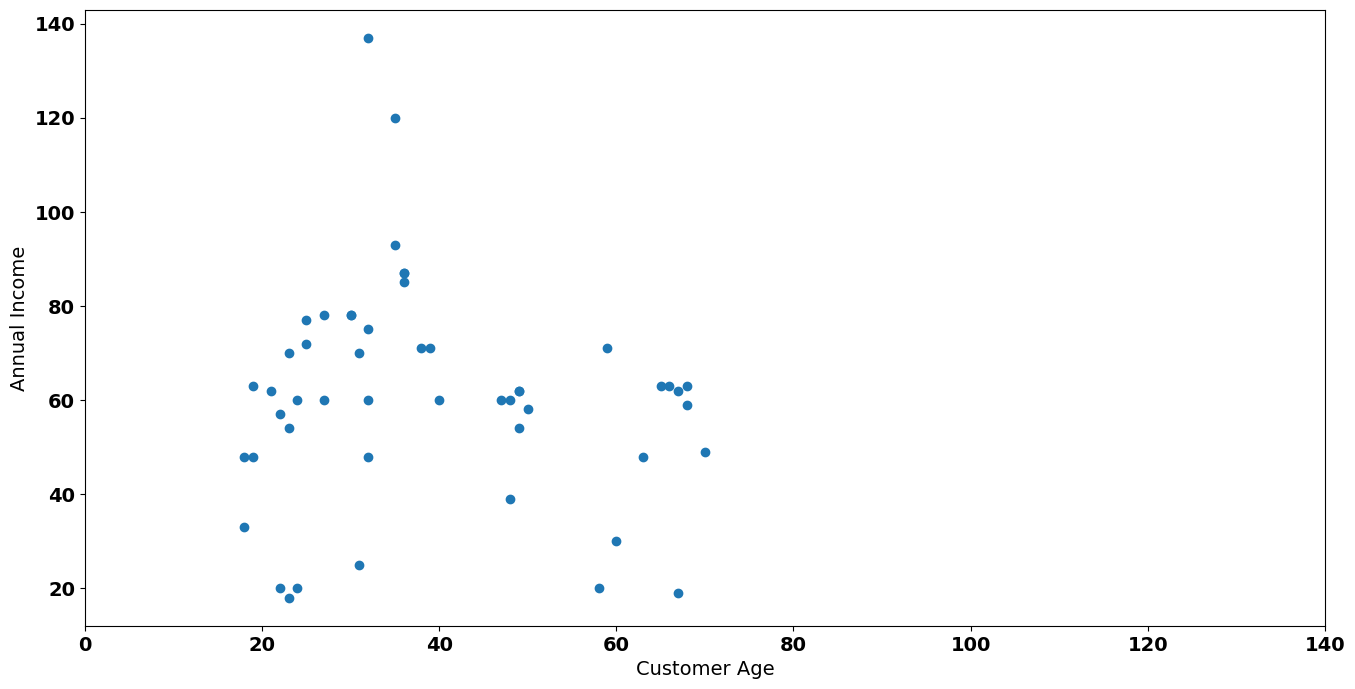

In [5]:
plt.scatter(customer_sample.age, customer_sample.annual_income)
plt.xlabel('Customer Age')
plt.ylabel('Annual Income')
plt.xlim(0, 140)

**How many groups of customers do you see here?**

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

Let's try to fit a `k-means` algorithm to this data, with 3 centroids:

In [6]:
kmeans_clust = KMeans(n_clusters = 3).fit(customer_sample)
customer_sample['kmeans_clustering'] = kmeans_clust.predict(customer_sample)

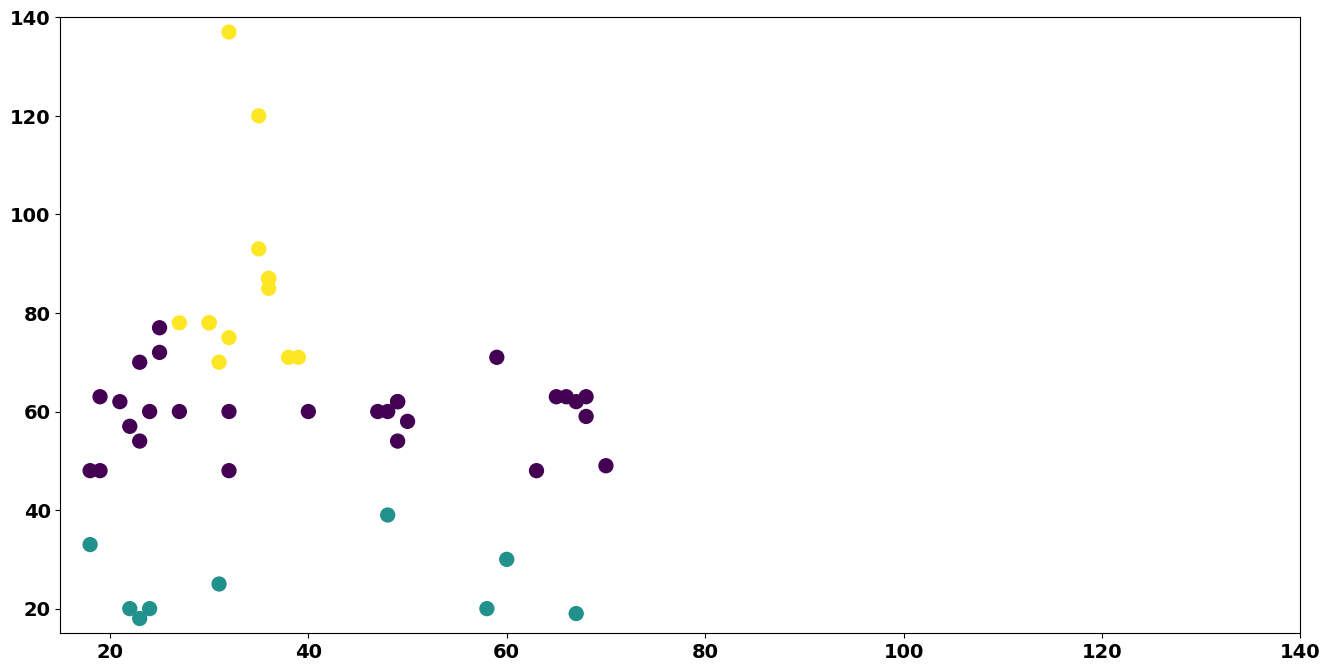

In [7]:
plot_clusters(customer_sample, 'kmeans_clustering', True)

Unfortunately, k-means has some issues dealing with these types of patterns that involve some type of packed points. Other distance-based clustering methods can't also deal with this pattern (that we, as humans can very well).
<br>
<br>
Hierarchical clustering will suffer the same fate:

In [8]:
customer_sample['ward_clustering'] = AgglomerativeClustering(
    linkage = 'ward', n_clusters=3
    ).fit_predict(customer_sample[['age','annual_income']])
customer_sample['complete_clustering'] = AgglomerativeClustering(
    linkage = 'complete',
    n_clusters=3).fit_predict(customer_sample[['age','annual_income']])

An example with the `ward` method:

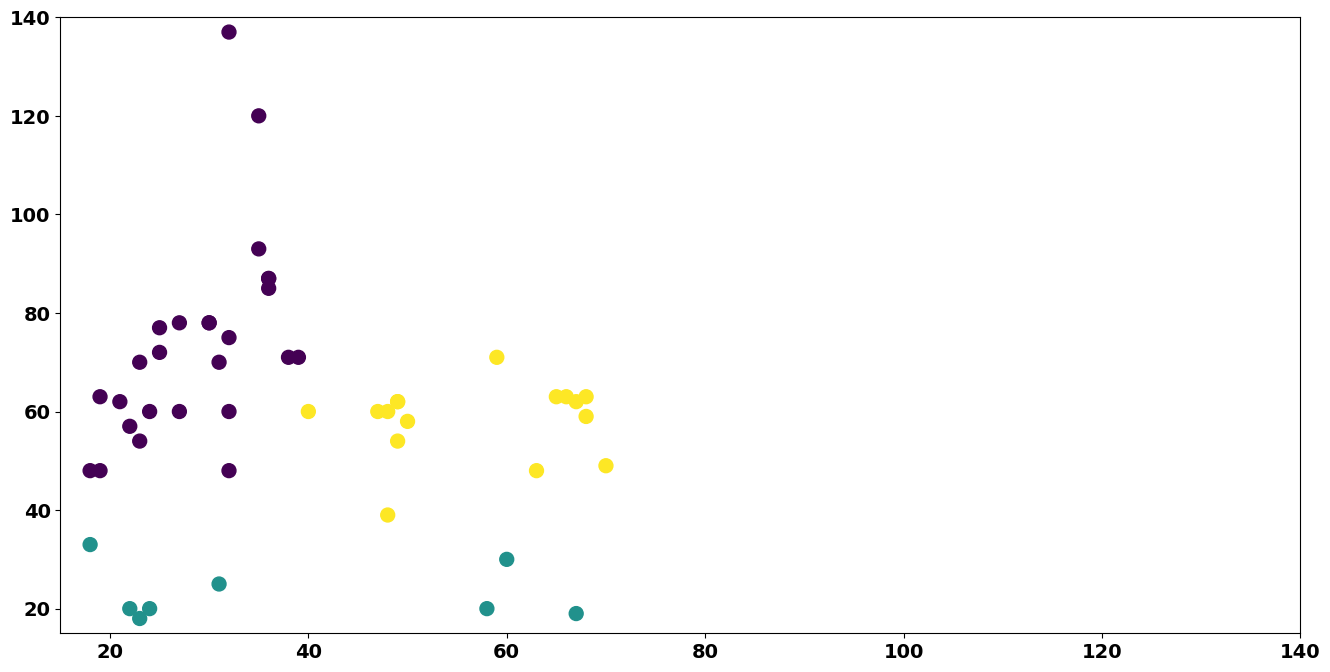

In [9]:
plot_clusters(customer_sample, 'ward_clustering', True)

And with `complete` clustering:

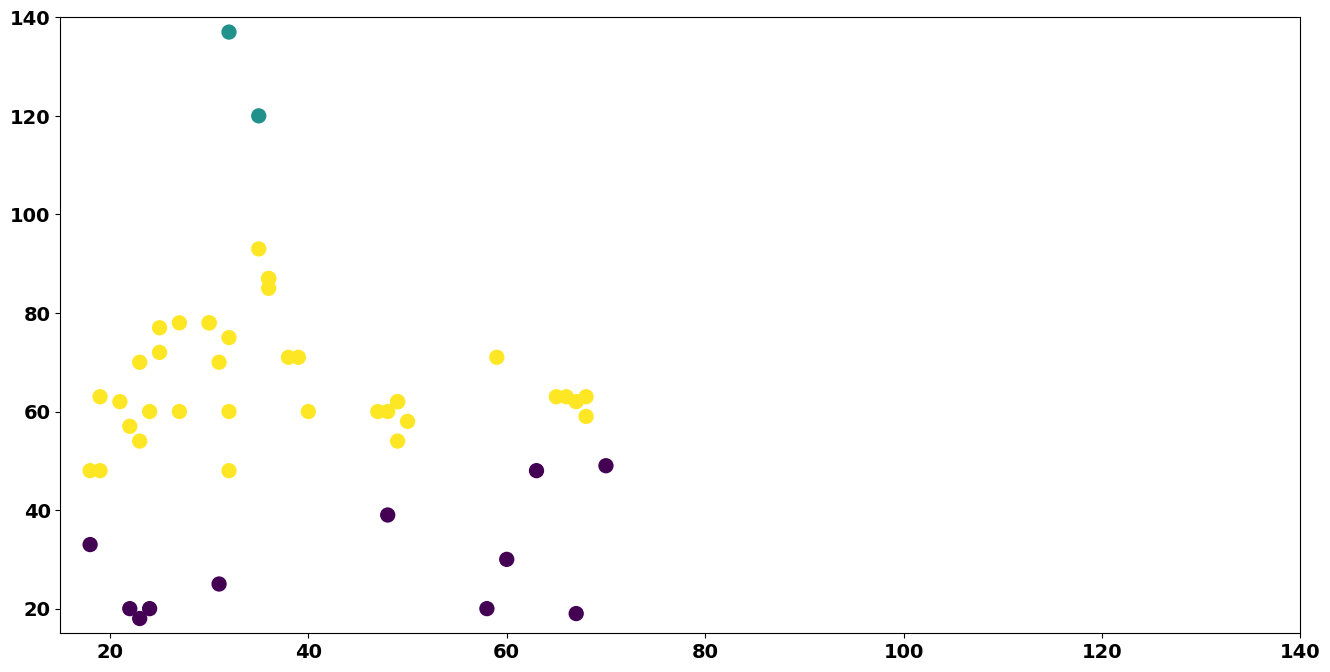

In [10]:
plot_clusters(customer_sample, 'complete_clustering', True)

Neither k-means nor hierarchical clustering seem to reach an optimum solution in terms of the data points we have. Let's discuss how **dbscan** can help.
<br>
<br>
**dbscan is density based and tries to cluster points based on their density, instead of blindly looking at distances**. Two parameters are essential for dbscan:
*   *eps*: maximum distance to consider a neighbor point.
*   *min_samples*: the number of points to consider a point a "core point" of the cluster solution.

**dbscan** starts by randomnly initializing a cluster in a specific data point - for example, let's consider that `eps=9` and `min_samples=5`:

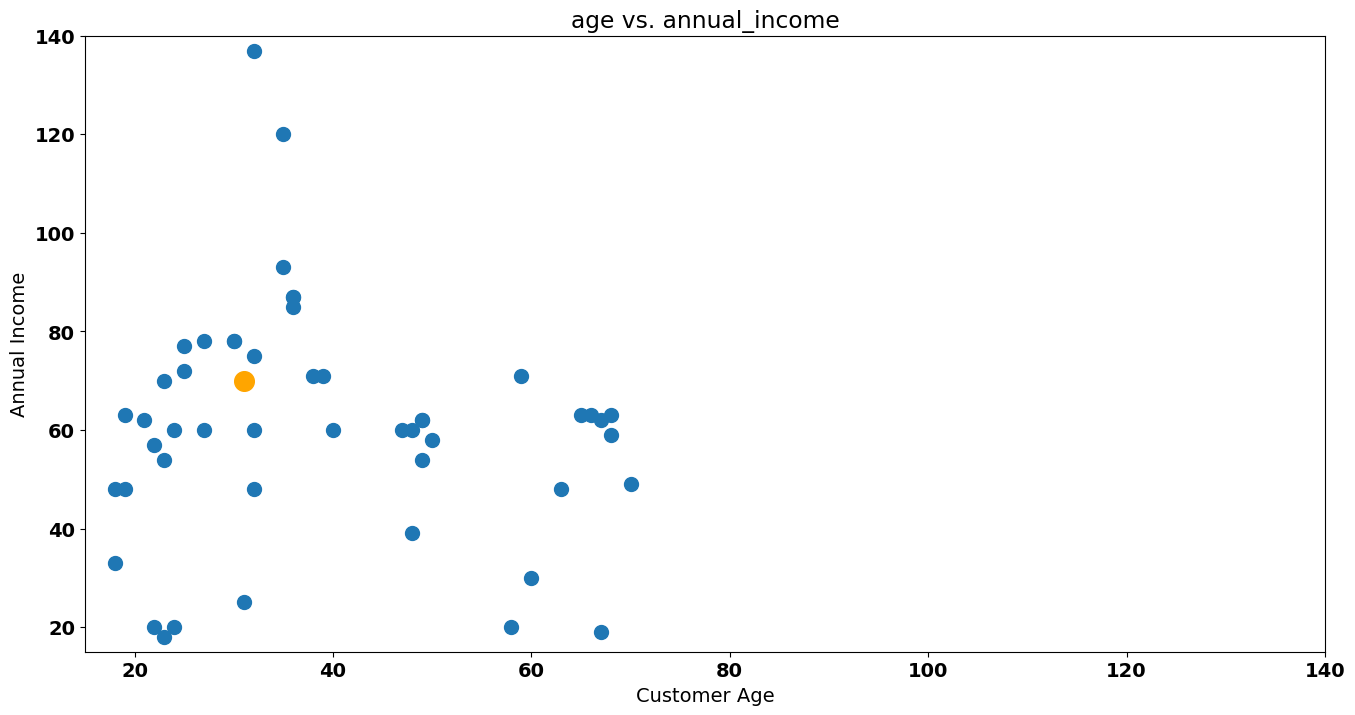

In [11]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[31, 70]],
    True)

From this point, we draw a radius equal to the *eps* parameter:

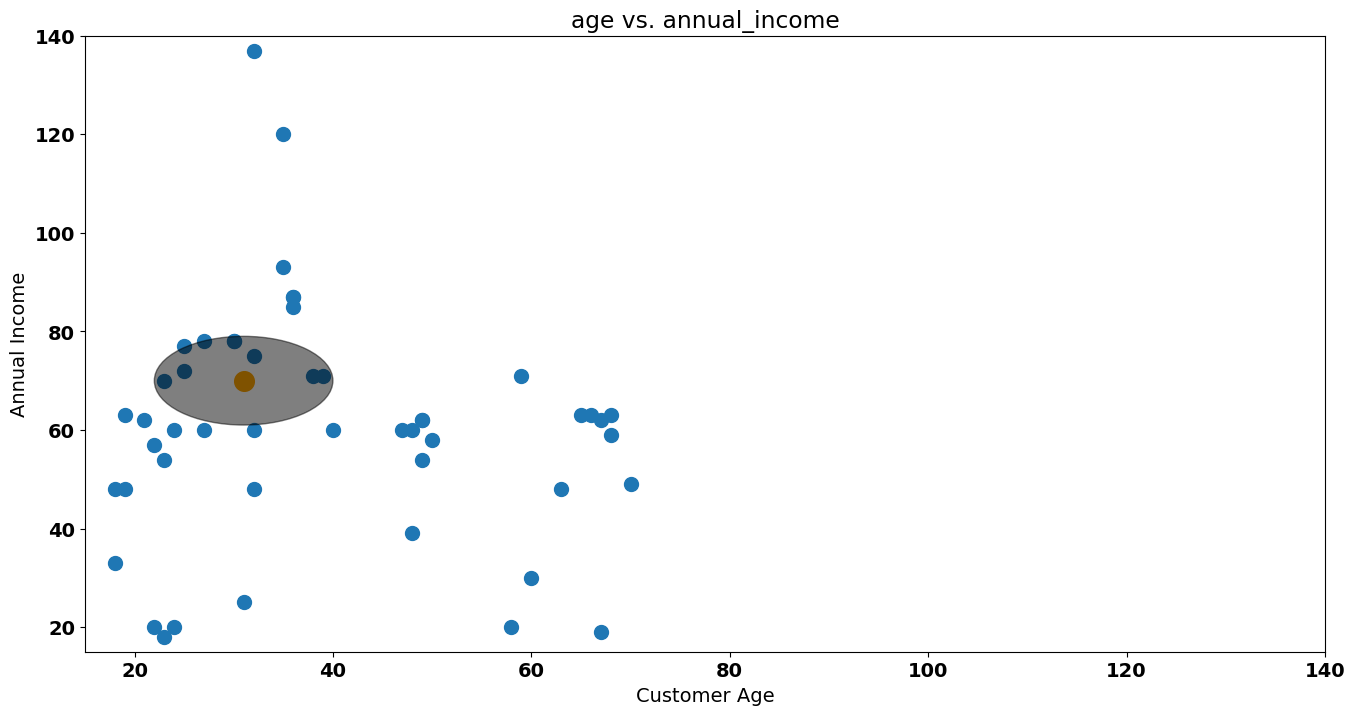

In [12]:
fig, ax = plt.subplots()
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[31, 70]],
    True)

# Add Circle with radius = 9
circle = plt.Circle((31, 70), radius=9, color='black', fill='black', alpha=0.5)
ax.add_patch(circle)

*Note: matplotlib is a bit dumb drawing circles and draws visual ellipsis, but let's ignore that for now.*

How many points are does our radius touch? 10 (including the data point!) - this makes this core data point for a cluster as **points > min_samples**.
<br>
<br>
Being a core data point means that this point belongs to the "core" of this cluster!

What can we do next? Continue with the same reasoning for all the points within the radius of our core point:

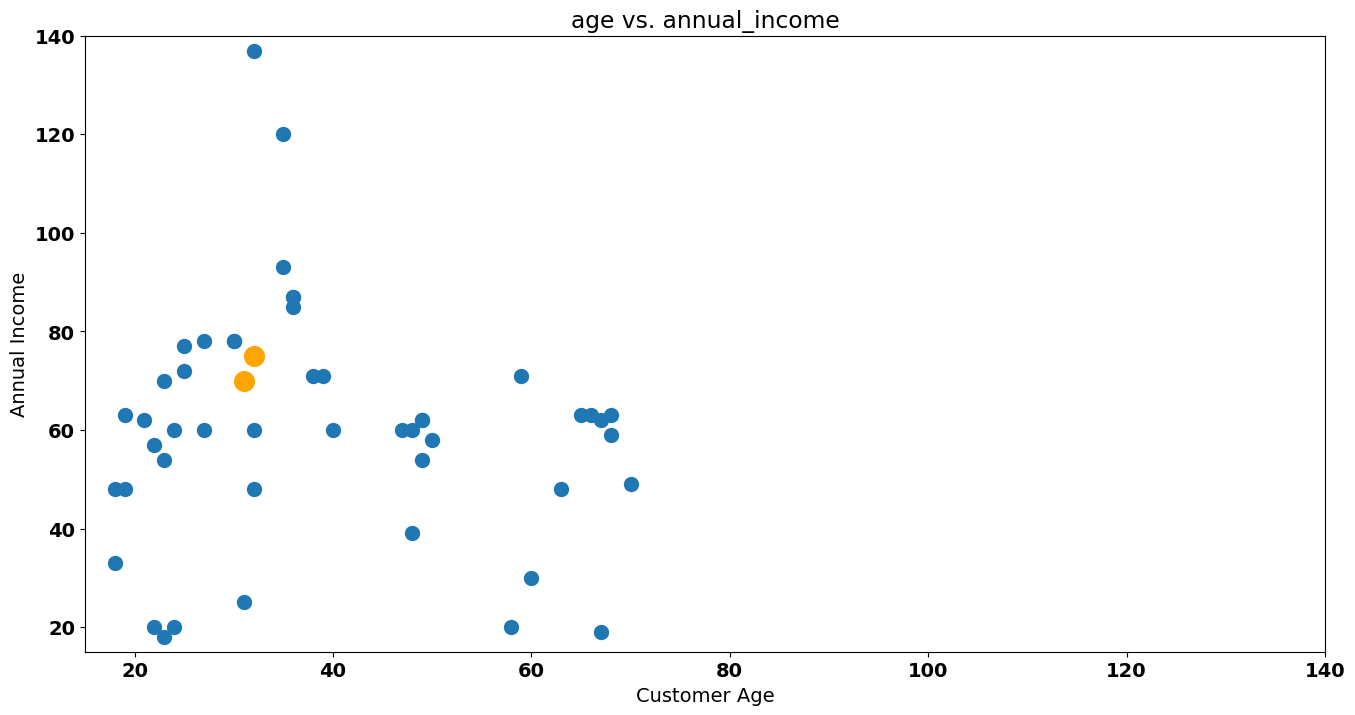

In [13]:
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[31, 70], [32, 75]],
    True)


**Is this a core point?**

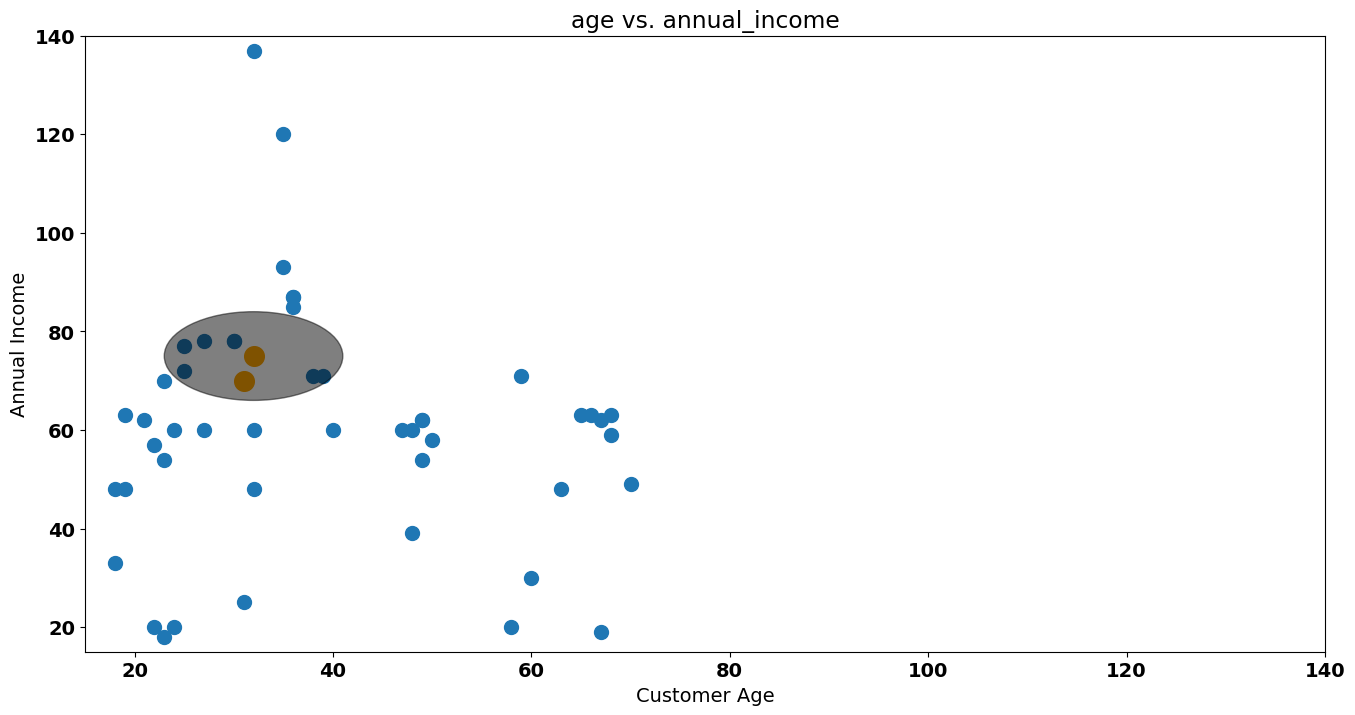

In [14]:
fig, ax = plt.subplots()
plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[31, 70], [32, 75]],
    True)

# Add radius around our new point
circle = plt.Circle((32, 75), radius=9, color='black', fill='black', alpha=0.5)
ax.add_patch(circle)

Yes, it is!
<br>
<br>
If we continue with this process, we will reach some candidates that have fewer points within their radius. For example, imagine that we were in a point that only contains 4 points on its radius:

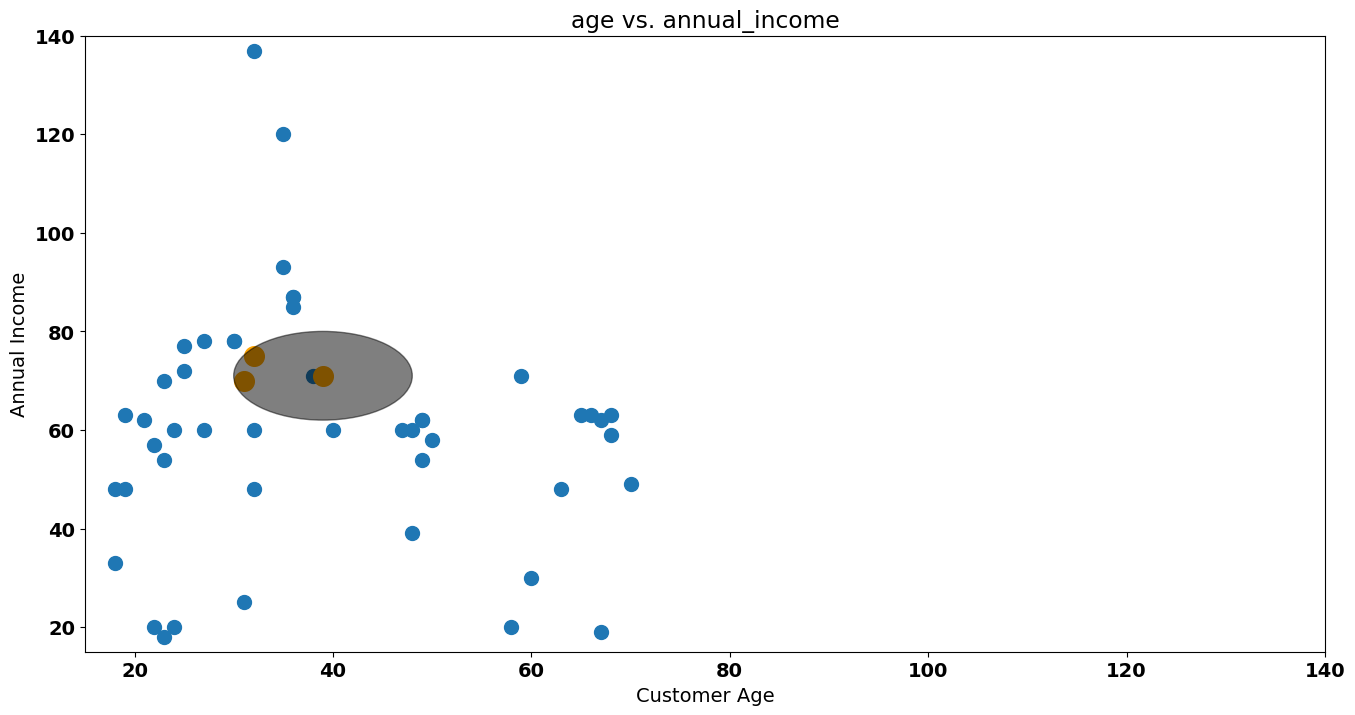

In [15]:
fig, ax = plt.subplots()

plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[31, 70], [32, 75], [39, 71]],
    True)

# Add circle to the new point
circle = plt.Circle((39, 71), radius=9, color='black', fill='black', alpha=0.5)
ax.add_patch(circle)

As this point contains less neighboring points than **min_samples**, it is considered a satellite (or non-core) point. **Only the point will enter the cluster and not it's neighbors.**
<br>
<br>
This process will continue until all points are either:
*  Assigned as core points to some cluster.
*  Assigned as satellite points to some cluster.
*  Only assigned as satellite points (they weren't *scanned* by any core point), meaning that they are noise.

Let's see the implementation of *DBSCAN* in `sklearn`:

In [16]:
# Using fit_predict to get fit the algorithm and obtain cluster class
# immediately

customer_sample['dbscan_clustering'] = DBSCAN(
    eps=9, min_samples=5
    ).fit_predict(customer_sample[['age','annual_income']])

This first `dbscan` solution leaves a lot of points as "noise" - points represented by class `-1`:

In [17]:
customer_sample['dbscan_clustering'].value_counts()

,count
dbscan_clustering,
-1,19
0,19
1,7
2,5


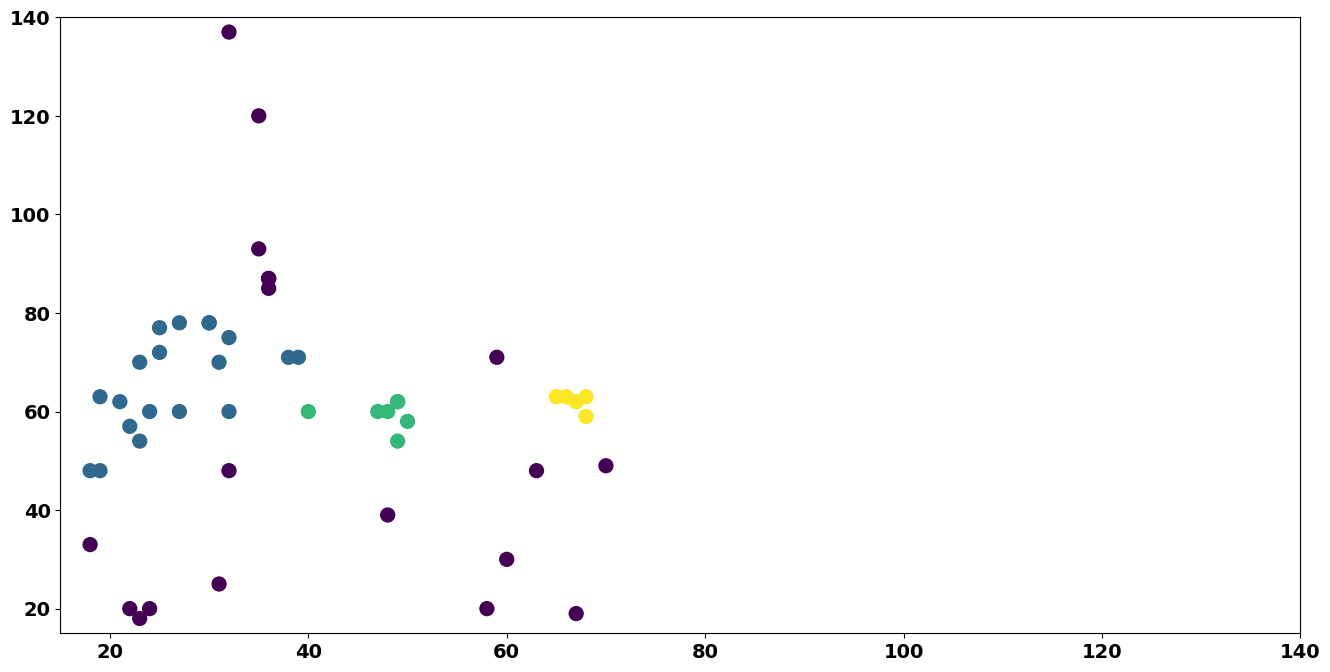

In [18]:
plot_clusters(customer_sample, 'dbscan_clustering', True)

Purple points are considered "outliers" and do not belong to any cluster. Of course, we can be less strict by either augmenting the radius or lowering the number of neighbouring points:

In [19]:
customer_sample['dbscan_clustering_less_strict'] = DBSCAN(
    eps=12, min_samples=4
    ).fit_predict(customer_sample[['age','annual_income']])

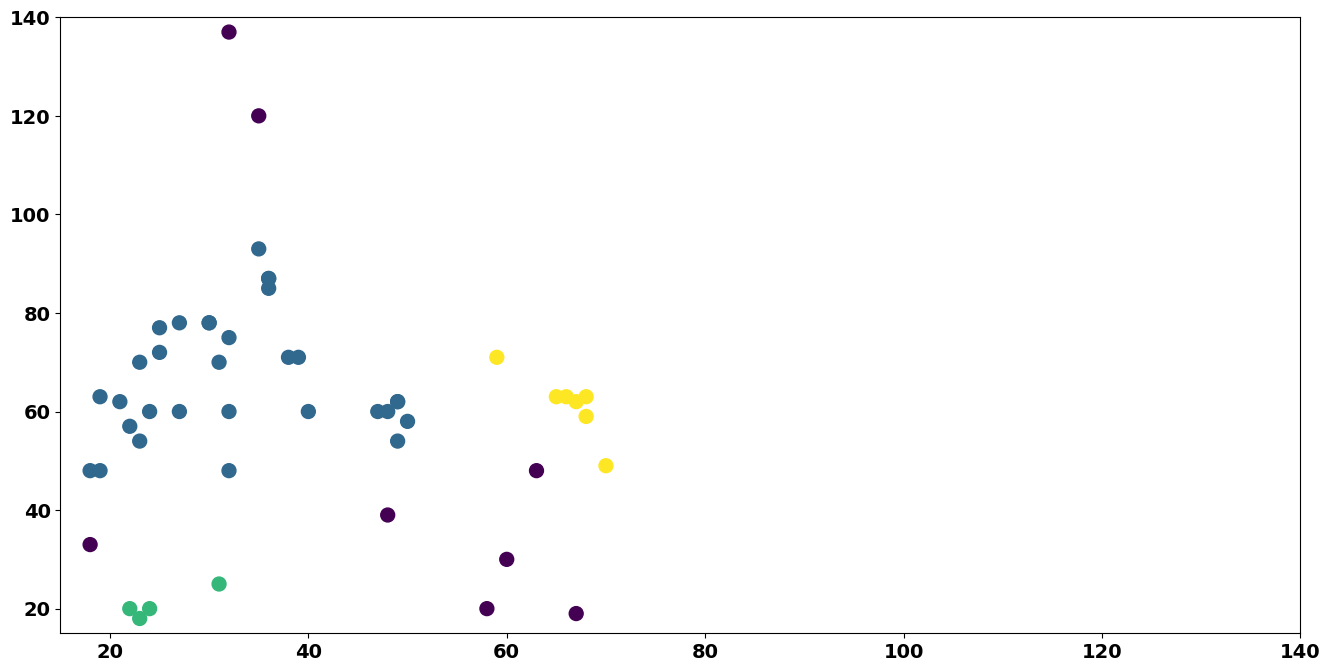

In [20]:
plot_clusters(customer_sample, 'dbscan_clustering_less_strict', True)

Notice that two clusters merge with these new parameters while a new cluster is born in the lower part of the plot!
<br>
<br>
Play around with these parameters to see how your clustering solution changes. Some usages of `dbscan` include:

* Customer segmentation in marketing.

* Fraud detection.

* Anomaly detection in sensor data.

* Clustering in bioinformatics.

## Mean-Shift Algorithm

**dbscan** is not the only density based algorithm! Another example of a density based clustering method is **mean-shift**.
<br>
<br>
Let's start by describing the true mean of the data points we have:

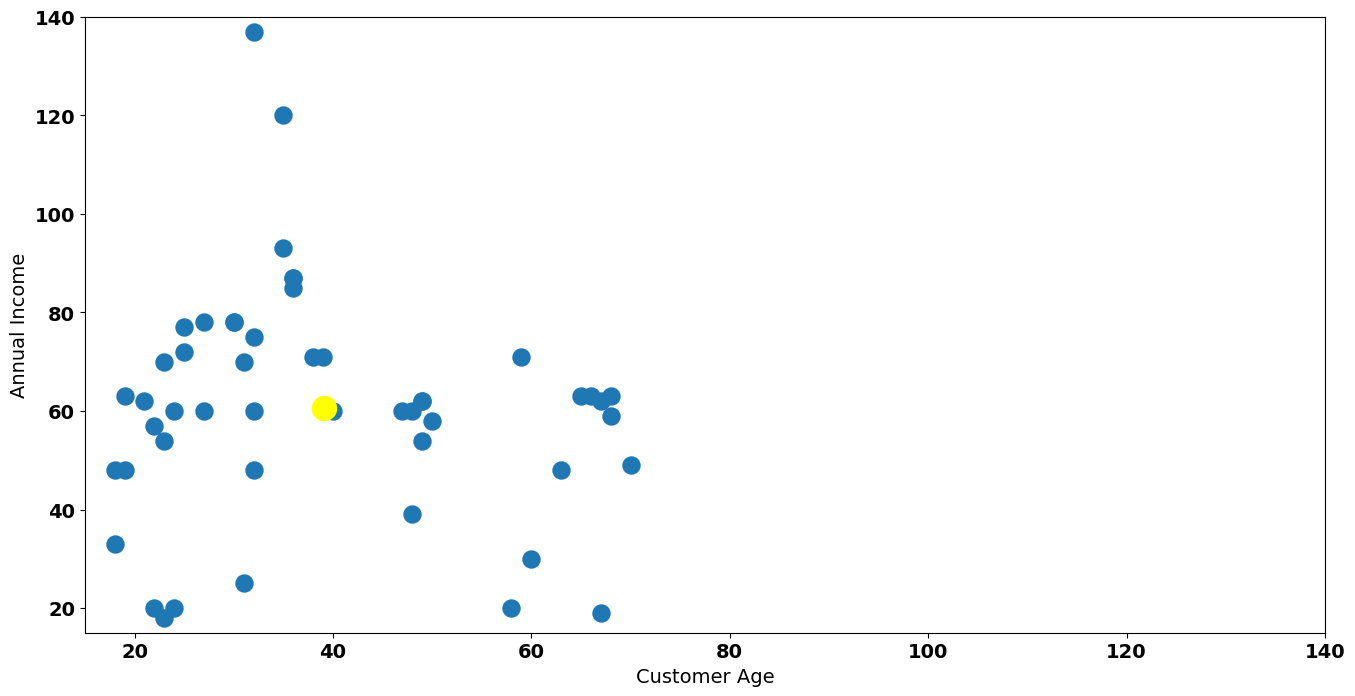

In [21]:
plt.scatter(
    customer_sample.age, customer_sample.annual_income, s=150
    )
plt.scatter(
    customer_sample.age.mean(), customer_sample.annual_income.mean(),
    color='yellow', s=300
    )
plt.xlim(15, 140)
plt.ylim(15, 140)
plt.xlabel('Customer Age')
plt.ylabel('Annual Income')
plt.show()

Now let's consider that we will calculate a **mean based on a radius around some point**:

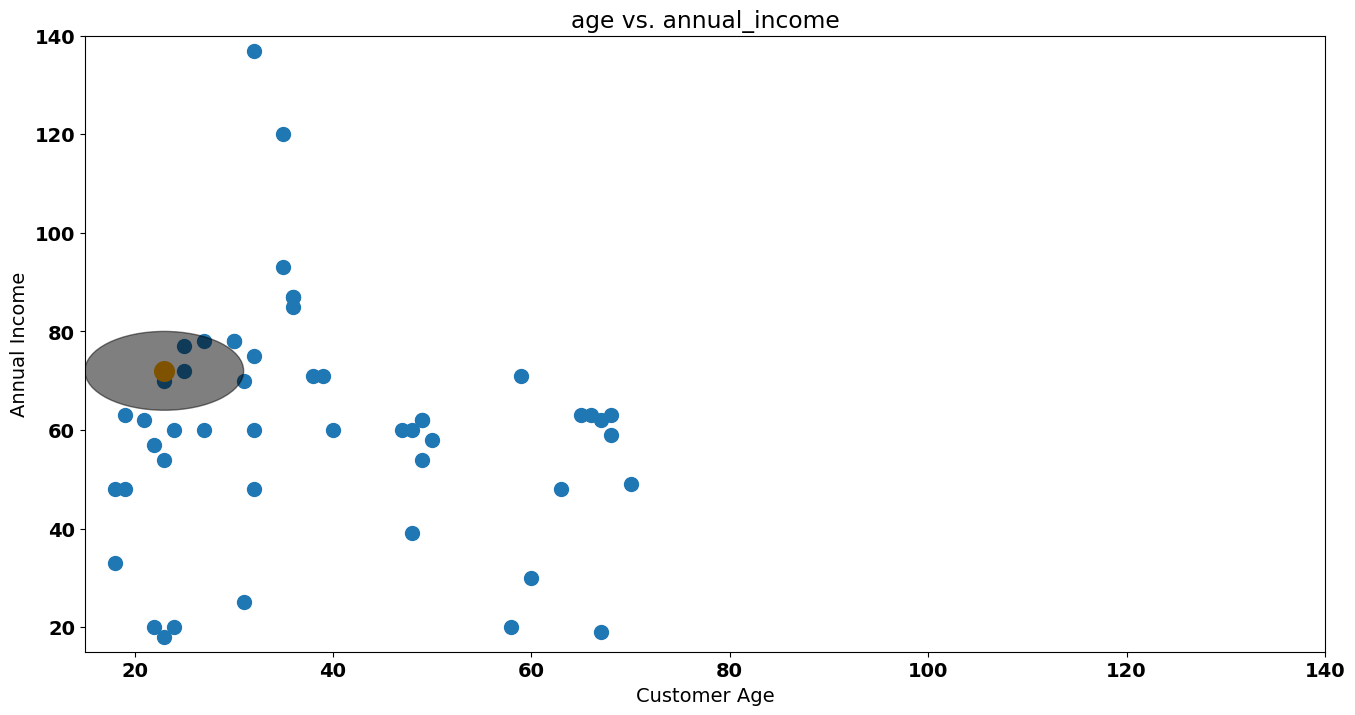

In [22]:
fig, ax = plt.subplots()


plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[23, 72]],
    True)

# Draw circle with radius = 8 around point
circle = plt.Circle((23, 72), radius=8, color='black', fill='black', alpha=0.5)
ax.add_patch(circle)
plt.show()

What's the true mean of the points that touch the radius? Let's filter them:

In [23]:
# Points inside the radius are..
radius_1 = customer_sample.loc[
    (customer_sample.age > 20) & (customer_sample.age < 32)
    &
    (customer_sample.annual_income > 63) & (customer_sample.annual_income < 80)
]

In [24]:
radius_1

,customer_id,age,annual_income,average_spending,kmeans_clustering,ward_clustering,complete_clustering,dbscan_clustering,dbscan_clustering_less_strict
155,156,27,78,89,2,0,2,0,0
159,160,30,78,73,2,0,2,0,0
132,133,25,72,34,0,0,2,0,0
124,125,23,70,29,0,0,2,0,0
157,158,30,78,78,2,0,2,0,0
125,126,31,70,77,2,0,2,0,0
144,145,25,77,12,0,0,2,0,0


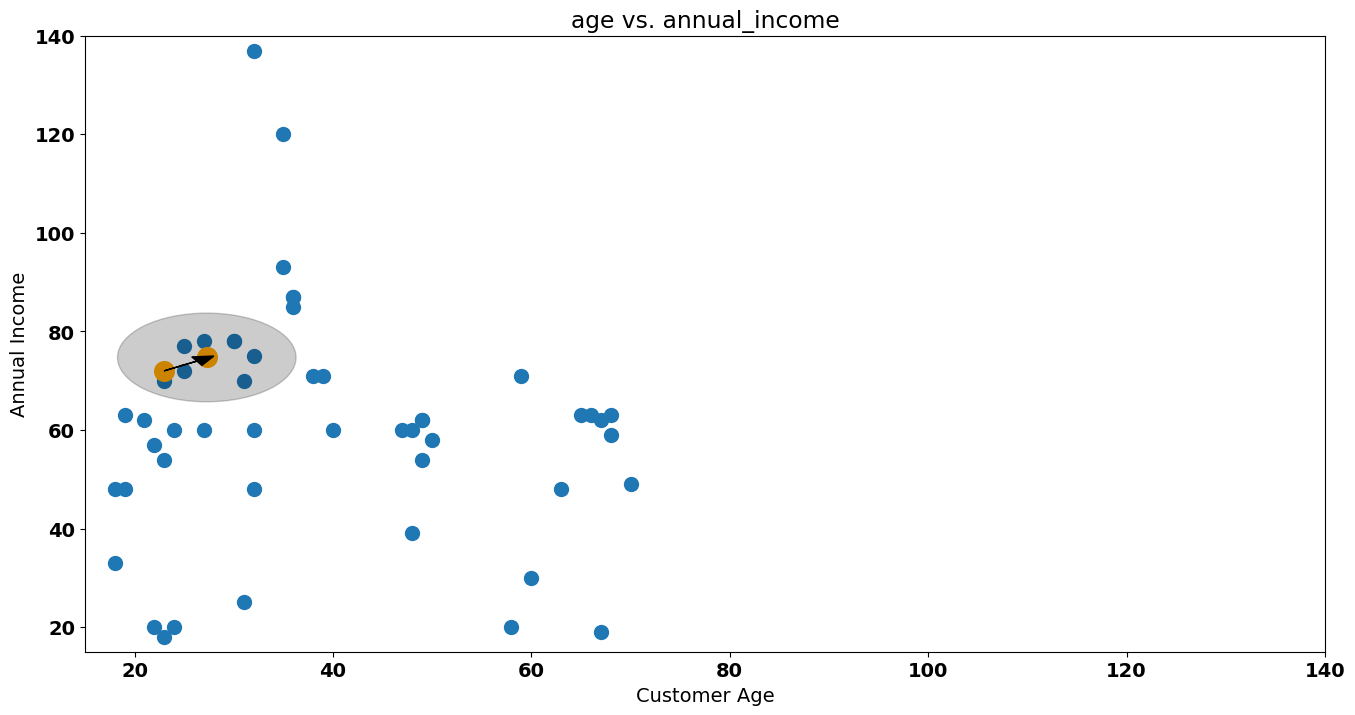

In [25]:
fig, ax = plt.subplots()


plot_centroids(
    customer_sample,
    'age',
    'annual_income',
    'Customer Age',
    'Annual Income',
    [[23, 72], [radius_1.age.mean(), radius_1.annual_income.mean()]],
    True)


# Adding an arrow representing the shift
plt.arrow(23, 72, 5, 3,
          head_width=2, head_length=2, length_includes_head=True, color='black')

# Adding new radius
circle = plt.Circle((radius_1.age.mean(), radius_1.annual_income.mean()), radius=9, color='black', fill='black', alpha=0.2)
ax.add_patch(circle)
plt.show()

This new point is the arithmetic mean between all the points in the radius. **Our mean was shifted towards a region with more density!**
<br>
<br>
The arrow on the plot above is what we call the *mean-shift vector*.
<br>
<br>
This radius can take any kernel - a weighted average, a normal distribution density estimation, any function that we want to represent our data points.

Naturally, the lower our radius, the larger the number of clusters as more "centroids" will show up in the data and shifted. Let's test this with the `sklearn` implementation by first using a really small **bandwidth** (think of bandwidth as the argument that represents the radius) - the `rbf kernel` used in the `sklearn` implementation is a smoothed version of the explanation above:

In [26]:
meanshiftmodel = MeanShift(bandwidth=0.2)
customer_sample['meanshift_clustering'] = meanshiftmodel.fit_predict(
    customer_sample[['age','annual_income']]
)

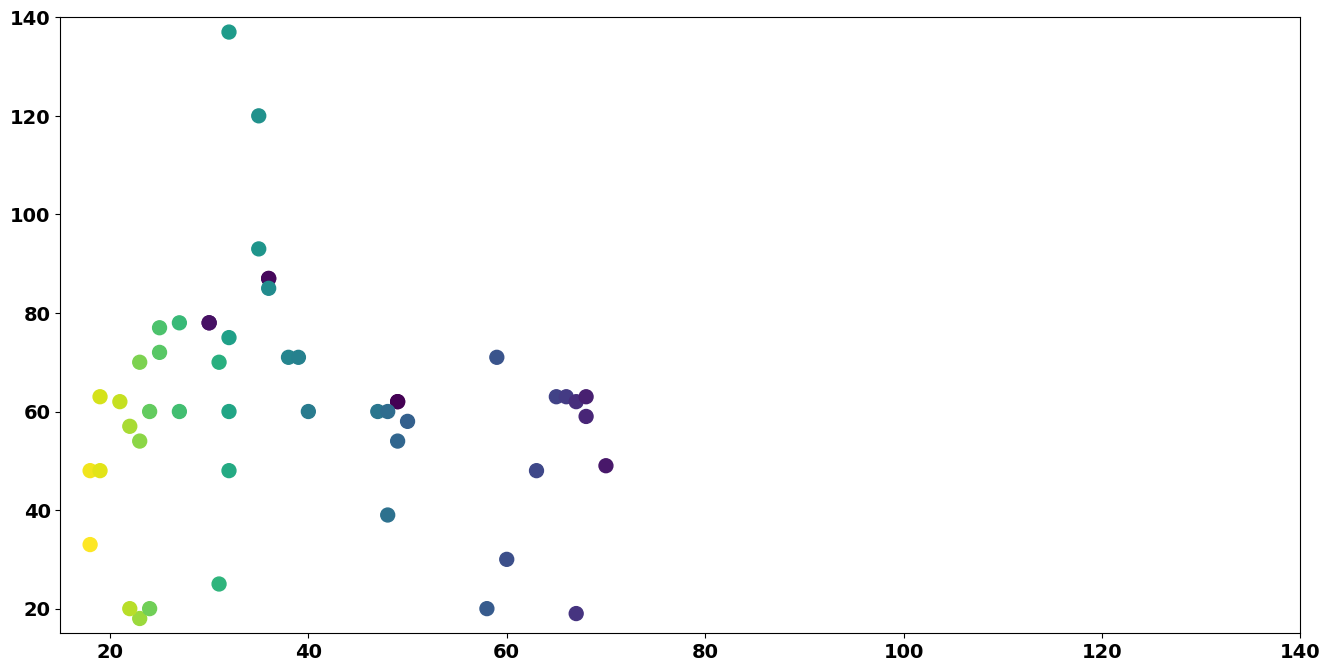

In [27]:
plot_clusters(customer_sample, 'meanshift_clustering', True)

As our bandwinth is too small, we produce too many clusters - there are too many "centers" for the algorithm to consider and only a couple of points packed together will be considered as a cluster:

In [28]:
# Let's count the number of elements per cluster
customer_sample.meanshift_clustering.value_counts()

,count
meanshift_clustering,
2,2
1,2
0,2
30,1
18,1
31,1
24,1
9,1
12,1


Let's see which examples were grouped in our tiny bandwidth solution by selecting clusters 0, 1 and 2:

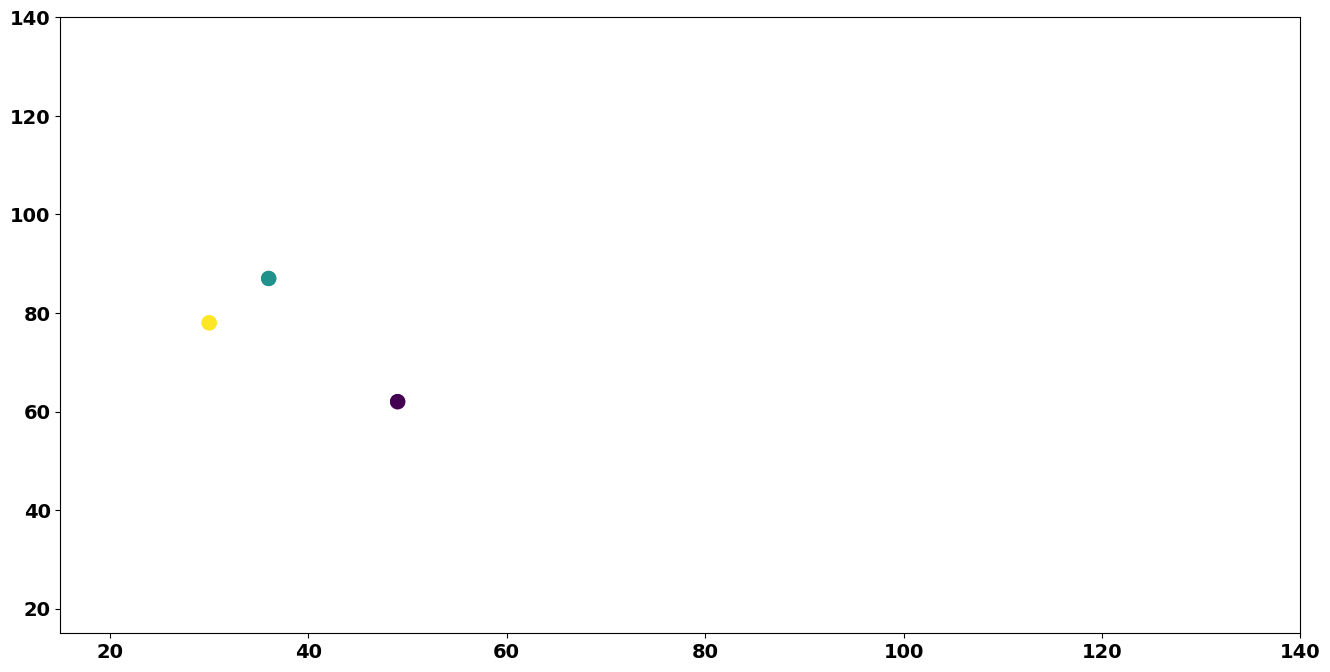

In [29]:
customer_sample_bandwidth = (
    customer_sample[customer_sample.meanshift_clustering.isin([0,1,2])]
)

plot_clusters(customer_sample_bandwidth, 'meanshift_clustering', True)

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

In truth - only customers that have **exactly** the same values were clustered together with such a low bandwidth. Let's raise this parameter and see the impact:

In [30]:
meanshiftmodel = MeanShift(bandwidth=20)
customer_sample['meanshift_clustering_20'] = meanshiftmodel.fit_predict(
    customer_sample[['age','annual_income']]
    )

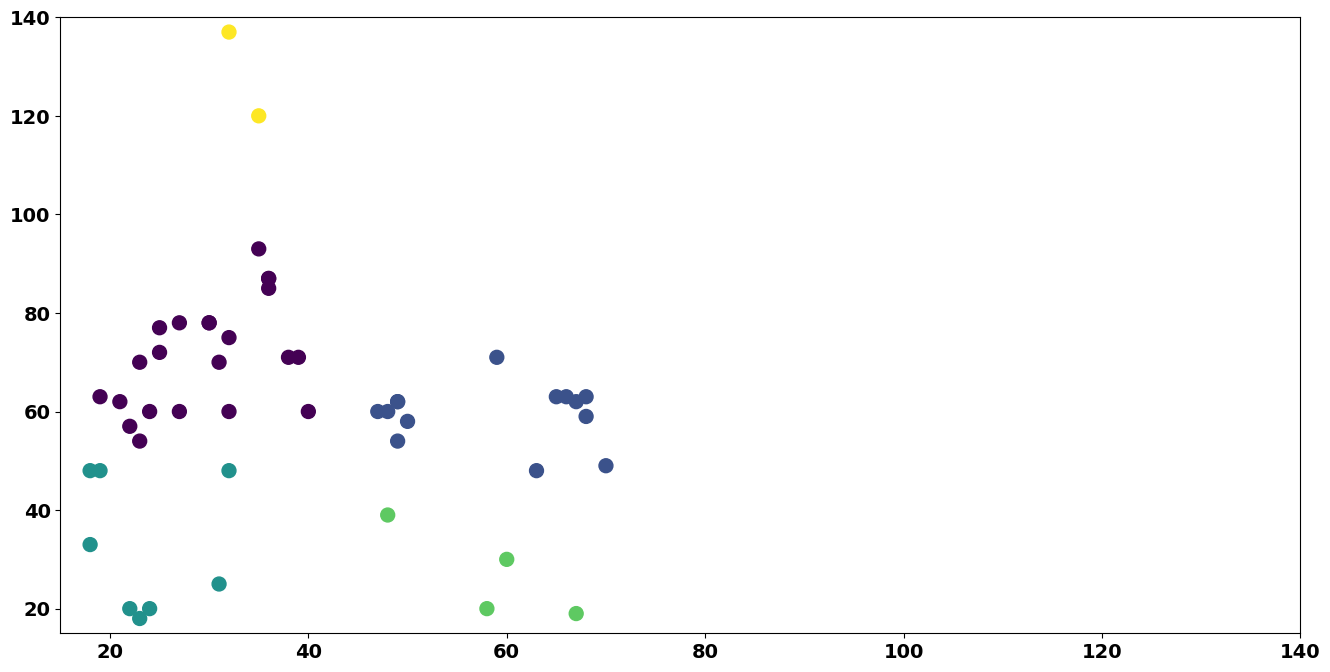

In [31]:
plot_clusters(customer_sample, 'meanshift_clustering_20', True)

Much better! Let's now see the distribution of customers by our clusters:

In [32]:
customer_sample.meanshift_clustering_20.value_counts()

,count
meanshift_clustering_20,
0,22
1,14
2,8
3,4
4,2


# Practical Example!

Let's do two examples on using density based algorithms:
- One example with image segmentation.
- In the exercise section, we'll use an example with spatial analysis.

Starting with our image segmentation example - we'll use images of animals to understand if density based clustering may be a solution to consider:

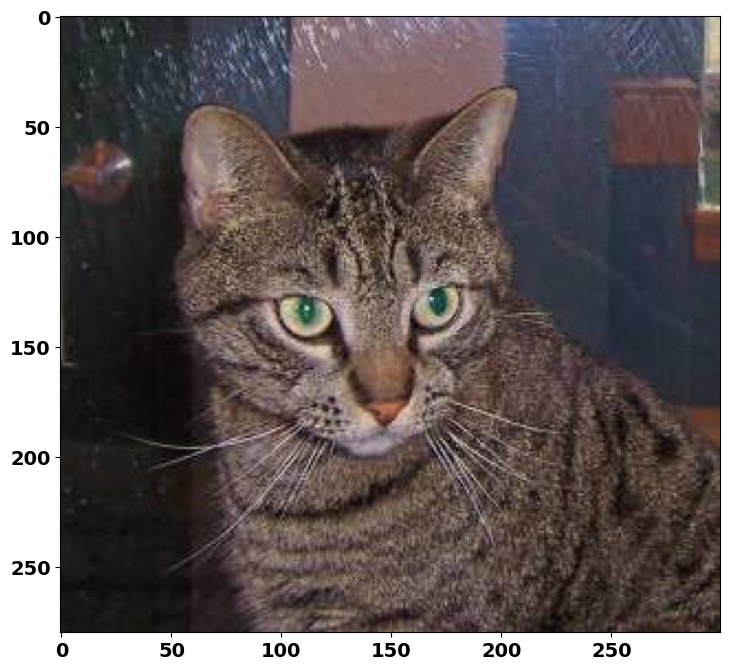

In [47]:
img = Image.open("/content/data/dogs_cats/cat.1.jpg")
plt.imshow(img)

Can we detect the animal on the image with clustering based methods? Or even try to understand if there's some type of uniformity in the image?

In [48]:
list_images = os.listdir('/content/data/dogs_cats/')

In [49]:
# Sort the images to retain indexes
list_images.sort()

Let's pick up an arbitrary image of a dog or cat and load it into `numpy` format:

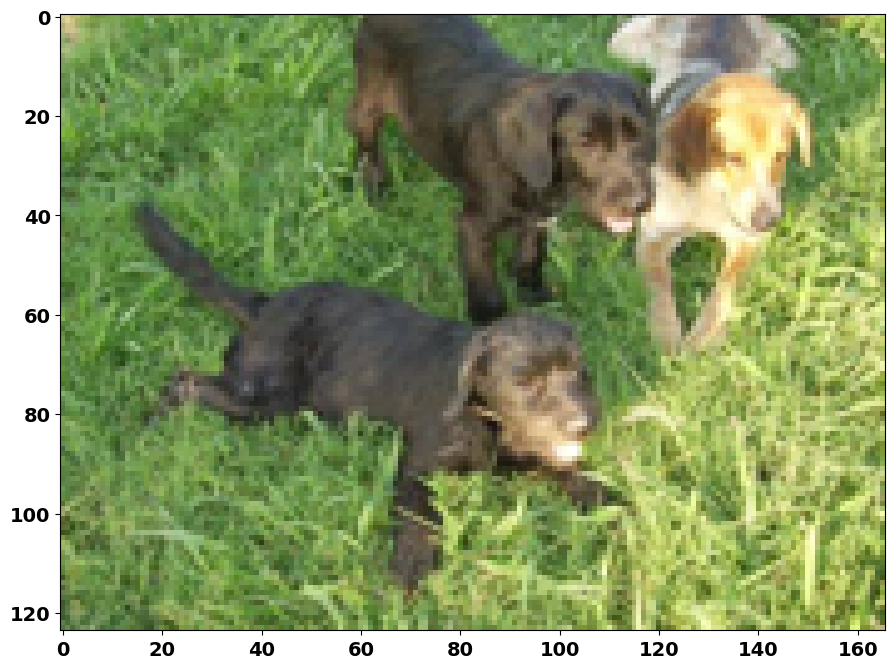

In [50]:
example_image, x_data = get_image(list_images, 17)

plt.imshow(example_image)

Let's start with MeanShift - what's the **bandwidth** we should use? There are many techniques we can use to do that (like dimensionality reduction, as we will learn!) but let's start by using the `estimate_bandwidth` function from `sklearn`.

In [51]:
bandwith_estimation = estimate_bandwidth(x_data)
bandwith_estimation

np.float64(1.5094043462349018)

I'll use this bandwidth inside the `MeanShift` algorithm - this may  take a while to run (this is a downside of `MeanShift`, it is computationally expensive - `bin_seeding` speeds up the process!):

In [52]:
ms = MeanShift(bandwidth = bandwith_estimation, n_jobs=-1, bin_seeding=True)
ms.fit(x_data)

MeanShift(bandwidth=np.float64(1.5094043462349018), bin_seeding=True, n_jobs=-1)

Let's visualize our segmented image!

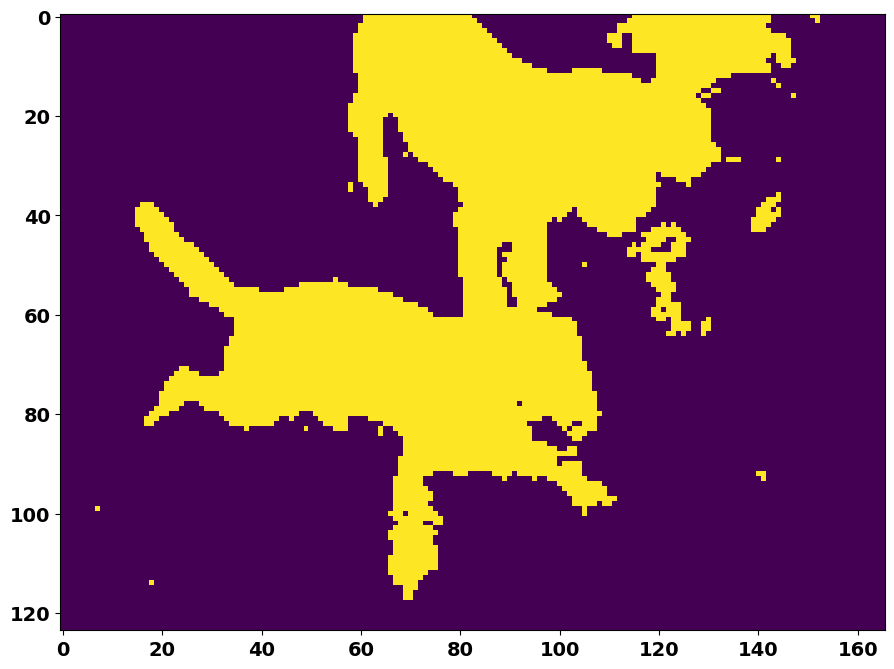

In [39]:
clusters = ms.labels_
clusters = clusters.reshape(example_image.size[1], example_image.size[0])
plt.imshow(clusters)
plt.show()

Cool! Notice that we are identified the black doggos very well! Although the other dog is not being targeted that well - this is because meanshift (and other clustering algorithms) are very good to identify objects based on "color".
<br>
<br>
We can use the `mark_boundaries` example to overlap our clusters and the real image:

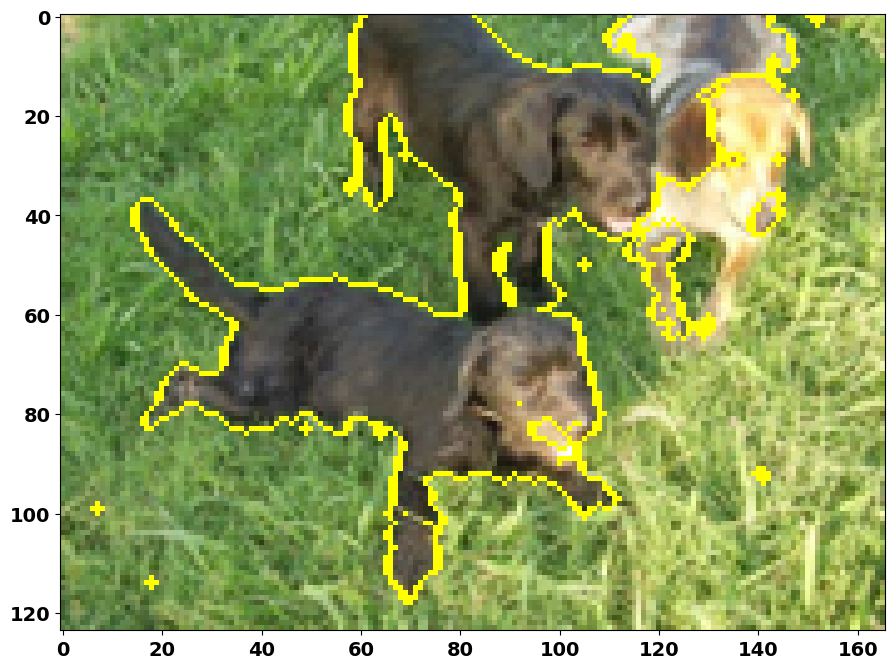

In [40]:
marked_image = mark_boundaries(np.array(example_image), clusters)
plt.imshow(marked_image)
plt.show()

How many clusters do we have with the `mean-shift`algorithm?

![discuss](https://cdn-icons-png.flaticon.com/512/1189/1189168.png)

Can we fit a `dbscan` solution?

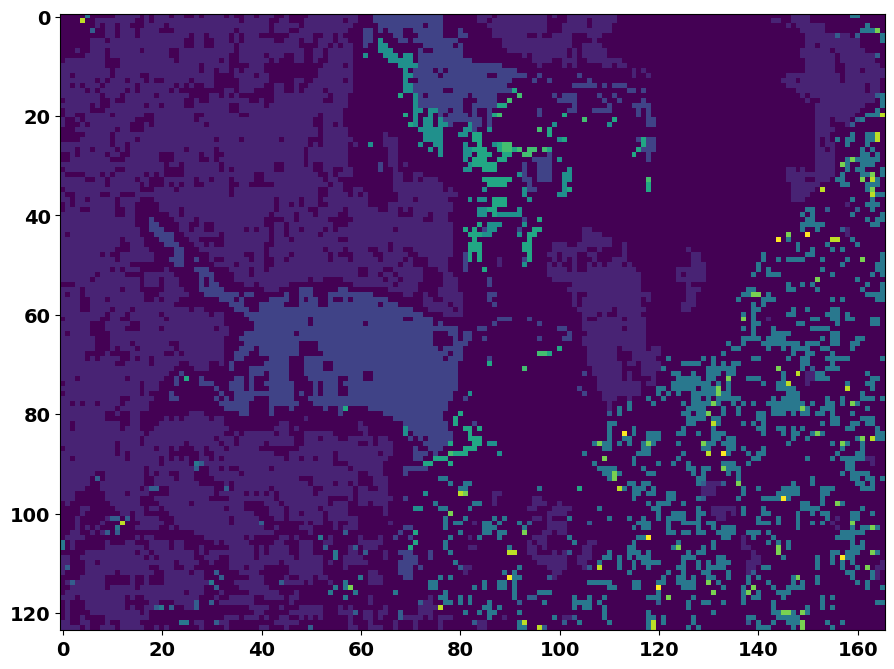

In [41]:
# dbscan results:
clusters = DBSCAN(eps=0.1, min_samples=20).fit_predict(x_data)
clusters = clusters.reshape(example_image.size[1], example_image.size[0])
plt.imshow(clusters)
plt.show()

For this image segmentation (and these types of images) `dbscan` is having a hard time. For other problems `dbscan` can be a good solution, particularly when we have restrictions regarding the distance that we want to force in our clusters - we'll see this in the pratical exercise.

Let's build an image segmentation pipeline using `MeanShift`. I'll leave this function in the notebook so that we can have a good view on a typical image segmentation pipeline:

In [42]:
def segment_image_results(list_images, image_index):
  '''
  Fits MeanShift algorithm to image and plots boundaries
  on top of image.

  Arguments:
  - list_images(list): List of image names in the dog_cats folder.
  - image_index(int): Index of image from the dog_cats folder.

  Returns:
  - None, but image with segmented clusters is shown.
  '''

  # Get image and segmented array
  example_image, x_data = get_image(list_images, image_index)

  # Fits meanshift with estimated bandwidth
  ms = MeanShift(bandwidth = estimate_bandwidth(x_data), n_jobs=-1, bin_seeding=True)
  ms.fit(x_data)

  # Products clusters
  clusters = ms.labels_
  clusters = clusters.reshape(example_image.size[1], example_image.size[0])

  # Plot image with boundaries
  marked_image = mark_boundaries(np.array(example_image), clusters)
  plt.imshow(marked_image)

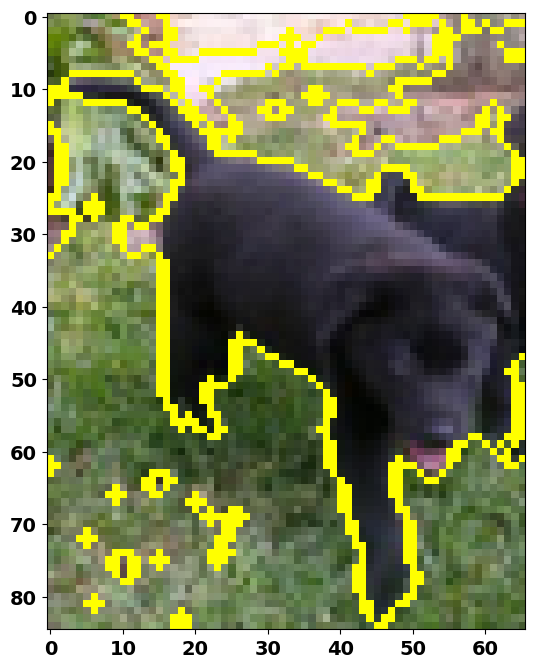

In [43]:
segment_image_results(list_images, 25)

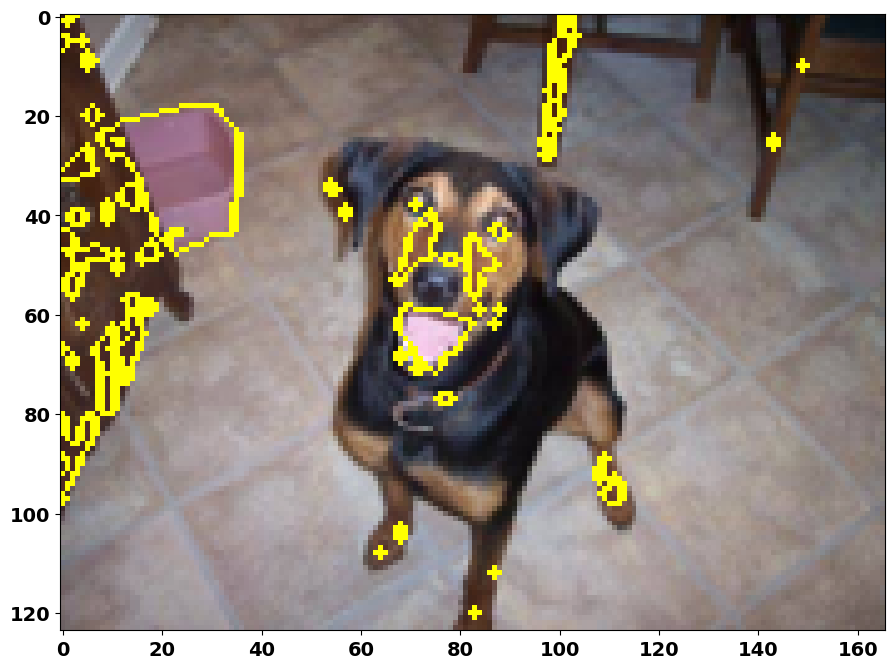

In [44]:
segment_image_results(list_images, 30)

Sometimes, even with estimated bandwith, we may have poor results:

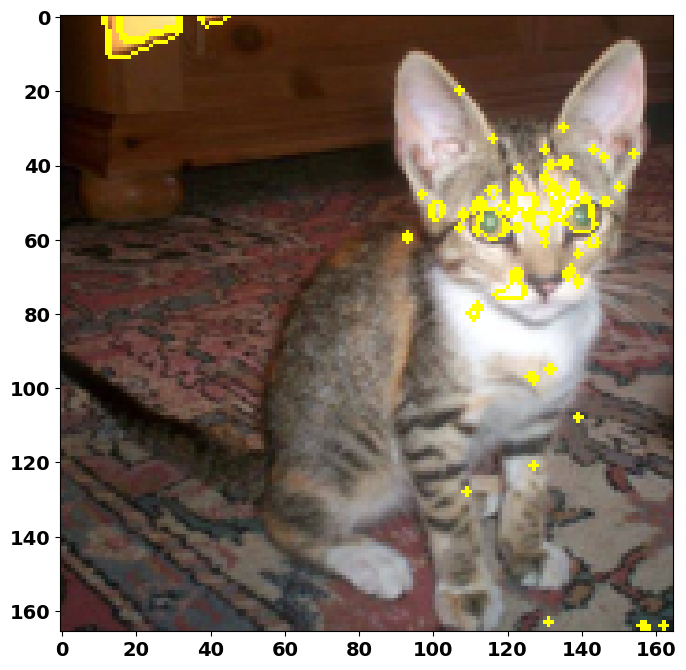

In [45]:
segment_image_results(list_images, 12)

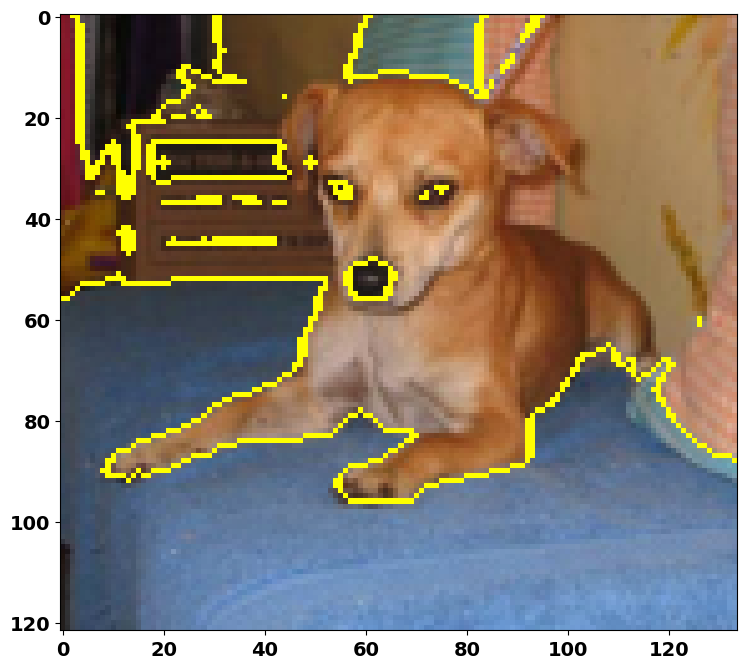

In [46]:
segment_image_results(list_images, 28)

Just like other clustering techniques, density based algorithms are very dependent on the hyperparameters we choose.
<br>
<br>
Using either `dbscan` or `meanshift` results really depends on how your data is organized.
<br>
<br>
In the computer vision examples we've just seen, we got completely different results for different images - nevertheless, this segmentation can be useful to annotate data and we can (maybe) pass these clusters into a CNN that can detect these objects much better, using the clustered labels.
<br>
<br>
In the practical exercise, we'll see an example where `dbscan` will be pretty useful!

# Exercise Section

### Exercise 1

Load the `taxi_data_sample.csv` file into a `taxi_data` dataframe.

In [ ]:
#### YOUR CODE HERE

### Exercise 2

Plot a 2D scatter plot with `pickup_latitude` on the y-axis and `pickup_longitude` on the x-axis.

In [ ]:
#### YOUR CODE HERE

### Exercise 3

The data is related to taxi's pickup and dropoffs in New York city. **Based on the map below, which points seem outliers?**
<br>
<br>
Note: Run the code below to set up the correct dependencies - you may need to restart the Colab Notebook to run the dependencies.

In [ ]:
!pip install cartopy==0.22
!apt-get -V -y -qq install python-cartopy python3-cartopy
!pip uninstall shapely -y
!pip install shapely --no-binary shapely

E: Unable to locate package python-cartopy
Found existing installation: shapely 2.0.4
Uninstalling shapely-2.0.4:
  Successfully uninstalled shapely-2.0.4
  Using cached shapely-2.0.4-cp310-cp310-linux_x86_64.whl


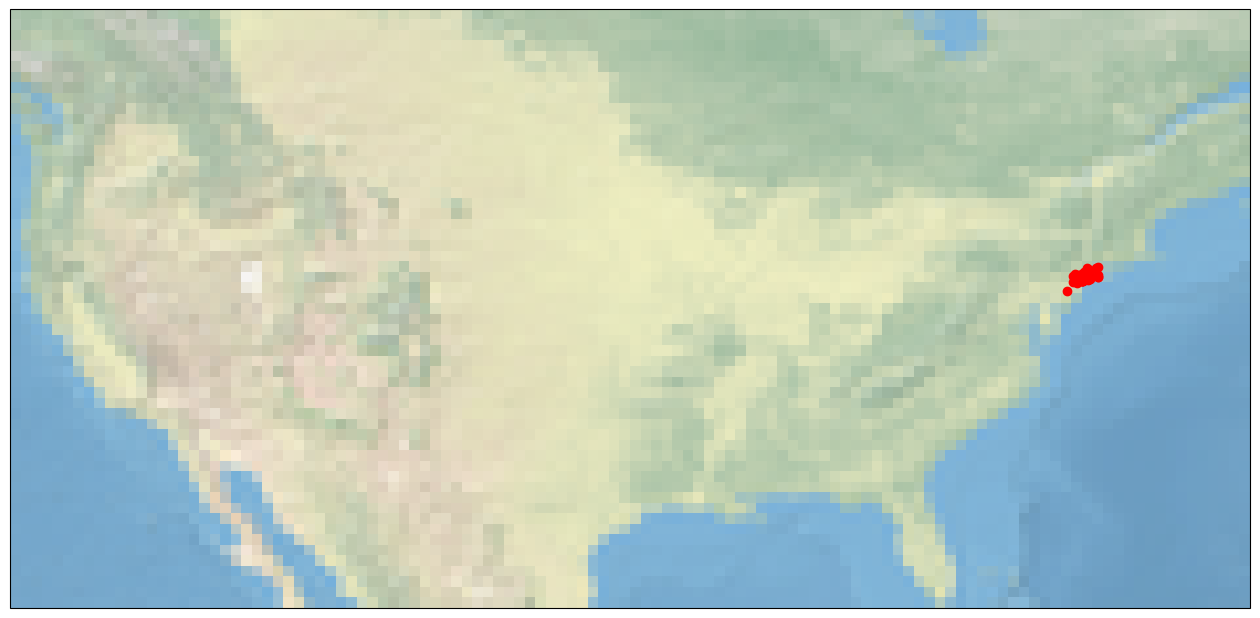

In [ ]:
import cartopy.crs as ccrs

ax = plt.axes(projection=ccrs.PlateCarree())

# Add the satellite image as the background of the map
ax.stock_img()
# Set the map extent to the area of interest
ax.set_extent([-125, -66, 25, 50])

# Plot the scatters on the map
plt.scatter(
    taxi_data.pickup_longitude,
    taxi_data.pickup_latitude,
    transform=ccrs.PlateCarree(), color='red', marker='o'
    )

### Exercise 4

Remove the data point in the west coast of the USA from the `taxi_data` dataframe. Rewrite the object. *Hint: Use the longitude column!*

In [ ]:
### YOUR CODE HERE

Confirm that your outlier was removed by viewing the map again:

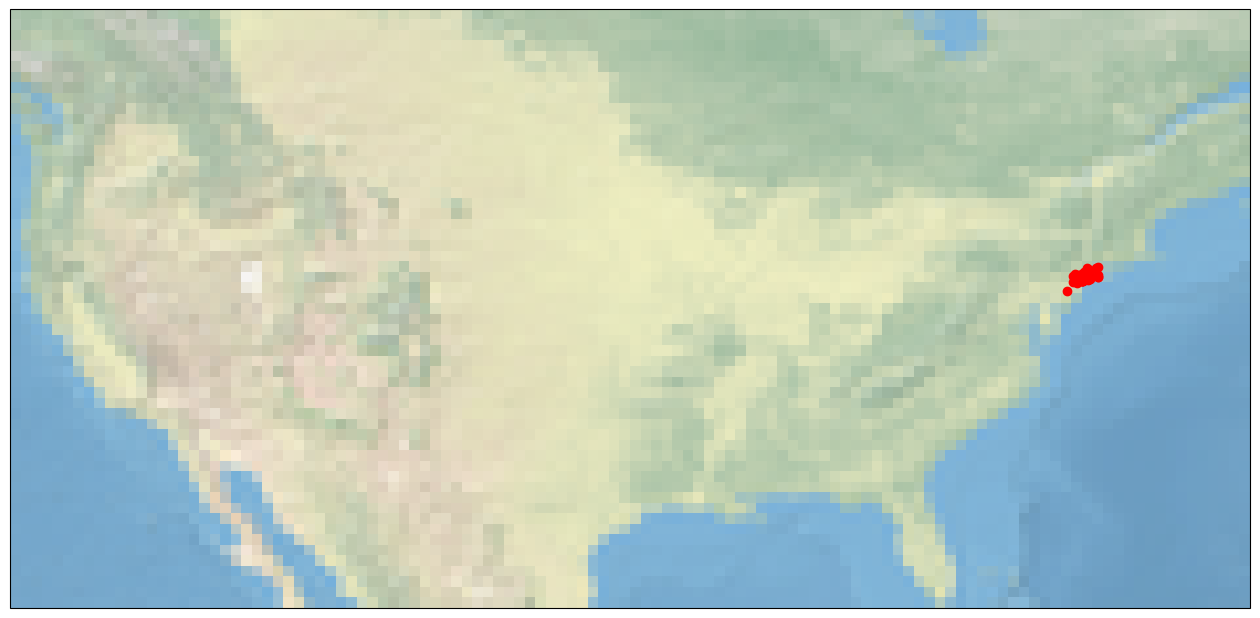

In [ ]:
ax = plt.axes(projection=ccrs.PlateCarree())

# Add the satellite image as the background of the map
ax.stock_img()
# Set the map extent to the area of interest
ax.set_extent([-125, -66, 25, 50])

# Plot the scatters on the map
plt.scatter(
   taxi_data.pickup_longitude,
   taxi_data.pickup_latitude,
   transform=ccrs.PlateCarree(), color='red', marker='o'
   )

Now let's view only New York City (sample of 20000 points to avoid Google Colab crashes):

In [ ]:
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=10)

np.random.seed(42)

pickup_points = taxi_data[['pickup_latitude', 'pickup_longitude']].sample(20000).values.tolist()
for point in pickup_points:
    folium.CircleMarker(location=point, radius=2, color='blue', fill=True, fill_color='blue').add_to(nyc_map)

In [ ]:
nyc_map

Output hidden; open in https://colab.research.google.com to view.

### Exercise 5

Imagining we are a taxi service company and we need to set up stations for our cab drivers.
<br>
<br>
Each stations has a restriction: it needs serve at least 100 trips of customers. Which algorithm would be more appropriate? `mean_shift` or `dbscan`?

-

### Exercise 6
Scale the `pickup_latitude` and `pickup_longitude` data using `StandardScaler`. Save the scaled data in a `scaled_taxi` variable.

In [ ]:
#### YOUR CODE HERE

### Exercise 7

Fit the mean shift algorithm on `scaled_taxi` with `bandwidth=1`. Use `bin_seeding = True` and save your fitted algorithm in a variable named `meanshift`.

In [ ]:
#### YOUR CODE HERE

### Exercise 8
Use the `meanshift` object to predict the cluster of each taxi trip. Add the prediction to the `taxi_data` with the name `cluster_meanshift`.

In [ ]:
#### YOUR CODE HERE

### Exercise 9

Do all clusters respect the restriction: have at least 100 taxi trips?
How many taxi stations (imagining each cluster is a taxi station) do we have to set up with this solution?

-

### Exercise 10

Calculate the centroids of each cluster and save them in a variable named `cluster_centroid`.

In [ ]:
### YOUR CODE HERE

### Exercise 11

Add the cluster centroids with an orange color to the map below:

In [ ]:
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=10)
#### YOUR CODE HERE

### Exercise 12
Fit a `dbscan` algorithm with `eps=0.25` and using `min_samples=100`. You can directly create a `cluster_dbscan` variable in the `taxi_data` dataframe with the generated clusters.

In [ ]:
#### YOUR CODE HERE

### Exercise 13
Calculate the `centroids` of `cluster_dbscan` and save them in a variable named `centroids_dbscan`.

In [ ]:
#### YOUR CODE HERE

### Exercise 14
Add the dbscan centroids to the plot below:

*Hint: Don't forget that dbscan may produce an outlier group!*

In [ ]:
nyc_map = folium.Map(location=[40.7128, -74.0060], zoom_start=10)
#### YOUR CODE HERE

### Exercise 15

Do all the dbscan clusters respect the restriction: have at least 100 expected taxi trips?
How many taxi stations (imagining each cluster is a taxi station) do we have to set up?

-